## LGP for RL

In [1]:
# Imports
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import copy
import time

LinearGeneticProgrammingSystem class, which controls the overall evolution

In [2]:
class LinearGeneticProgrammingSystem:
    """
    Overarching class controlling the LGP system
    """
    def __init__(self, binary_ops=None, unary_ops=None, population_size=100, max_generations=100, mutation_rate=0.1, crossover_rate=1, max_length=50, enforce_max_length=True):
        if binary_ops is None:
            self.binary_ops = ["ADD", "SUB", "MUL", "DIV", "GT", "EQ"]
        if unary_ops is None:
            self.unary_ops = ["LOAD", "SIN", "COS"]
        self.max_generations = max_generations
        self.population = []
        # Initialize population
        for i in range(population_size):
            new_program = Program(binary_ops=binary_ops, unary_ops=unary_ops, num_registers=8, max_length=max_length, enforce_max_length=enforce_max_length)
            new_program.generate_random_program()
            self.population.append(new_program)

        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate

        self.max_length = max_length
        self.enforce_max_length = enforce_max_length

        self.best_fitness_history = []
        self.checkpoint_generations = []    # the x value in a graph
        self.average_length_history = []    # the y value
        self.average_effective_length_history = []  # the 2nd y value

    def display_statistics(self):
        plt.plot(self.checkpoint_generations, self.best_fitness_history, label="Best Fitness")
        plt.xlabel("Generation")
        plt.ylabel("Fitness")
        plt.title("Best Fitness Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.plot(self.checkpoint_generations, self.average_length_history, label="Average length")
        plt.plot(self.checkpoint_generations, self.average_effective_length_history, label="Effective Length")

        plt.xlabel("Generation")
        plt.ylabel("Value")
        plt.title("Program Metrics Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

    def evolve(self, checkpoint=10, stop_if_converged=True, environments=["CartPole-v1"], reward_weights=[1], parsimony_coefficient=0.1):
        """
        Evolves the population
        """
        target_fitness = "max"      # maximizes fitness reward

        def evolution_checkpoint():
            """ Function to collect data at certain generation checkpoints, returns True if population converges """
            print("Generation", gen)
            print("Best program", best_program)
            print("Best fitness", best_fitness)
            self.checkpoint_generations.append(gen)
            self.best_fitness_history.append(best_fitness)
            total_length = 0
            effective_length = 0
            for program in self.population:
                total_length += len(program)
                effective_length += len(program.effective_indices)

            average_length = total_length / len(self.population)
            average_effective_length = effective_length / len(self.population)
            print("Average program length in population", average_length)
            print("Average effective code in population", average_effective_length)
            self.average_length_history.append(average_length)
            self.average_effective_length_history.append(average_effective_length)

            if stop_if_converged:
                best_history.append(best_fitness)  # add to history
                if len(best_history) > 2:
                    best_history.pop(0)  # remove oldest

                if len(best_history) == 2 and len(set(best_history)) == 1:  # past 2 checkpoints are equal
                    print("Converged at generation", gen)
                    return True

            return False

        def _tournament_selection(population, fitnesses, k=3, target_fitness="max"):
            tournament_indices = random.sample(range(len(population)), k=k)
            tournament_population = [population[i] for i in tournament_indices]
            tournament_fitness = [fitnesses[i] for i in tournament_indices]
            if target_fitness == "max":
                best_idx = np.argmax(tournament_fitness)
            elif target_fitness == "min":
                best_idx = np.argmin(tournament_fitness)
            else:
                print(f"Invalid mode {target_fitness}, choose from ['max', 'min']")
                return
            return tournament_population[best_idx]

        # Main loop
        best_history = []
        for gen in range(self.max_generations):
            # Evaluate population fitness
            fitnesses = []
            for program in self.population:
                fitnesses.append(self._evaluate(program, environments=environments, reward_weights=reward_weights, parsimony_coefficient=parsimony_coefficient))

            # Attempt at implemnenting multiprocessing but it did not speed up runtime since tasks are too small
            # Likely too much overhead cost when initializing gym environment for each evaluation
            # args = [(program, environment) for program in self.population]
            # with Pool() as pool:
            #     fitnesses = pool.starmap(self._evaluate, args)

            if target_fitness == "max":
                best_idx = np.argmax(fitnesses)
            else:
                best_idx = np.argmin(fitnesses)
            best_program = self.population[best_idx]
            best_fitness = fitnesses[best_idx]

            # checkpoint
            if gen % checkpoint == 0:
                if evolution_checkpoint():
                    break

            # Add previous best to new population (elitism)
            new_population = [best_program]

            # Generate next population
            while len(new_population) < len(self.population):
                if random.random() < self.crossover_rate:   # chance of crossover
                    parent1 = _tournament_selection(self.population, fitnesses, k=3, target_fitness=target_fitness)
                    parent2 = _tournament_selection(self.population, fitnesses, k=3, target_fitness=target_fitness)
                    child = parent1.crossover(parent2)
                else:
                    # otherwise, simply copies one individual from previous population
                    child = _tournament_selection(self.population, fitnesses, k=3, target_fitness=target_fitness)

                if random.random() < self.mutation_rate:
                    child = child.mutate(mutate_weight=1, insert_weight=1, delete_weight=1)

                new_population.append(child)

            # replace
            self.population = new_population

        # Run final checkpoint once finished
        evolution_checkpoint()
        return best_program, best_fitness

    def _evaluate(self, program, environments=["CartPole-v1"], reward_weights=[1], episodes=1, parsimony_coefficient=0.1):
        """
        This function tests a given program on the test cases
        program: Program object to be tested
        environments: list of strings named after the environments to be tested
        reward_weights: list of floats representing the relative weights of each environment reward
        episodes is the number of times each environment is tested with random initialization (exponentially increases runtime)
        parsimony_coefficient penalizes the size of the program's effective code
        """
        # Bounds checking
        if len(program) > self.max_length:
            if self.enforce_max_length:
                return -1   # give it poor fitness

        program.detect_introns()    # reset intron detection before evaluating

        environment_rewards = []
        for environment in environments:    # evaluate program in each given environment
            env = gym.make(environment)
            action_space = env.action_space

            # Measuring where major slowdown is
            # Both steps take roughly equal time ~0.01 for CartPole
            # Unless I can majorly speed up interpreting step it is not worth optimizing since simulation can't be sped up
            # For per individual time performance
            time_evaluating = 0
            time_simulating = 0
            for _ in range(episodes):  # average out fitness over 3 episodes
                episode_reward = 0
                obs, info = env.reset()
                done = False

                while not done:
                    # Run LGP program to produce an action
                    start_eval = time.perf_counter()
                    action = program.map_to_action_space(obs, action_space)
                    end_eval = time.perf_counter()
                    time_evaluating += end_eval - start_eval

                    start_sim = time.perf_counter()
                    obs, reward, terminated, truncated, info = env.step(action)
                    end_sim = time.perf_counter()
                    time_simulating += end_sim - start_sim
                    episode_reward += reward

                    done = terminated or truncated

                environment_rewards.append(episode_reward)

            env.close()

        penalty = len(program.effective_indices) * parsimony_coefficient  # penalize programs for length

        total_reward = 0
        for reward, weight in zip(environment_rewards, reward_weights):
            total_reward += reward * weight

        return (total_reward / episodes) - penalty

Program class, which represents an individual program

In [3]:
class Program:
    """
    Class defining an individual program
    I modeled it after the ARM assembly language since I am familiar with it
    Each instruction is a list ["op", "dest", "input1", "input2"]
    """
    def __init__(self, binary_ops=None, unary_ops=None, num_registers=8, instructions=None, max_length=50, enforce_max_length=True):
        if binary_ops is None:
            self.binary_ops = ["ADD", "SUB", "MUL", "DIV", "GT", "EQ"]
        else:
            self.binary_ops = binary_ops
        if unary_ops is None:
            self.unary_ops = ["LOAD", "SIN", "COS"]
        else:
            self.unary_ops = unary_ops
        self.operations = self.binary_ops + self.unary_ops
        self.registers = {}                 # registers is a dict of {"r#": value}
        for i in range(num_registers):      # default of 8 registers
            self.registers["r" + str(i)] = 0.0
        self.constants = [-1, -0.5, 0, 0.5, 1]      # only used with LOAD op
        self.instructions = instructions if instructions else []
        self.effective_indices = []
        self.max_length = max_length
        self.enforce_max_length = enforce_max_length

    def __repr__(self):
        """
        Returns a string representation of its instructions, separated by newlines
        Only prints the effective instructions
        """
        effective_instructions = [self.instructions[index] for index in self.effective_indices]
        s = "[" + ",\n".join(str(x) for x in effective_instructions) + "]"
        return s

    def __len__(self):
        return len(self.instructions)

    def detect_introns(self):
        """
        Determine intron positions within the instructions
        Does a backwards pass through the instructions to mark effective
        Must be run before evaluating
        This function is called each time the program is altered (mutation, crossover)
        """
        self.effective_indices = []     # clears old
        needed = {"r0"}
        for i in range(len(self.instructions) - 1, -1, -1):     # iterate backwards through indices
            instruction = self.instructions[i]
            operation = instruction[0]
            destination = instruction[1]
            input1 = instruction[2]
            if operation in self.binary_ops:
                input2 = instruction[3]
            else:
                input2 = None

            if destination in needed:    # if destination branches from used and output registers
                self.effective_indices.append(i)
                needed.add(input1)
                if operation in self.binary_ops:    # uses 2nd input register
                    needed.add(input2)

        self.effective_indices.reverse()    # reverse list since it was built backwards
        # print(self.effective_indices)     # debugging
        return self.effective_indices

    def execute(self, inputs=None):
        """ Executes this program and returns the 0th register """
        # Initialize registers
        if inputs is None:
            inputs = []
        for i, input in enumerate(inputs):
            self.registers["r" + str(i)] = 0    # clears register first
            self.registers["r" + str(i)] = input

        if not self.effective_indices:  # safeguard
            # Mark effective code before running program
            self.detect_introns()

        # Run program
        instruction_index = 0   # enables skipping lines (not sure if I will implement)
        while instruction_index < len(self.effective_indices):
            instruction = self.instructions[self.effective_indices[instruction_index]]  # index only into effective
            operation = instruction[0]
            destination = instruction[1]
            input1 = instruction[2]
            if operation in self.binary_ops:
                input2 = instruction[3]
            else:
                input2 = None

            # # debugging
            # print(operation, destination, input1, input2)
            # if operation != "LOAD":
            #     print(self.registers[input1], self.registers[input2])

            # Definition of operations
            if operation == "ADD":
                output = self.registers[input1] + self.registers[input2]
            elif operation == "SUB":
                output = self.registers[input1] - self.registers[input2]
            elif operation == "MUL":
                output = self.registers[input1] * self.registers[input2]
                # if (abs(self.registers[input1]) > 1e-6) or (abs(self.registers[input2]) > 1e-6):
                #     output = self.registers[input1] * self.registers[input2]
                # else:   # if either value is close to 0, return 0
                #     output = 0
            elif operation == "DIV":  # protected division
                if abs(self.registers[input2]) > 1e-6:
                    output = self.registers[input1] / self.registers[input2]
                else:
                    output = 1     # failsafe
            # Conditionals return a 1 or 0
            elif operation == "GT":
                if self.registers[input1] > self.registers[input2]:
                    output = 1
                else:
                    output = 0
            elif operation == "EQ":   # not exactly equals, uses a threshold
                if abs(self.registers[input1]) - abs(self.registers[input2]) < 1e-4:
                    output = 1
                else:
                    output = 0
            elif operation == "LOAD": # loads a constant into a register
                output = input1
            elif operation == "SIN":
                output = math.sin(self.registers[input1])
            elif operation == "COS":
                output = math.cos(self.registers[input1])
            else:
                print(f"Invalid Instruction {operation}, operation is not supported")
                return

            output = max(min(output, 1e6), -1e6)    # clamp values to prevent overflow
            self.registers[destination] = output
            instruction_index += 1

        return self.registers["r0"]     # return 1st register

    def map_to_action_space(self, input, action_space):
        """ Wrapper functino for program execution which instead maps the output to an action space """
        def _map_continuous_to_discrete(x, low=-1, high=1, n_bins=2):
            """ Used to map continuous program output to discrete environment input """
            delta = (high - low) / n_bins  # width of each bin
            idx = int((x - low) / delta)  # index into bin
            return max(0, min(n_bins - 1, idx))  # clamps to valid range

        program_output = self.execute(input)

        # Map output based on environment's action space
        if isinstance(action_space, spaces.Discrete):
            # Maps program output to n bins evenly divided across the range [-1, 1]
            action = _map_continuous_to_discrete(program_output, low=-1, high=1, n_bins=action_space.n)

        elif isinstance(action_space, spaces.Box):
            # Convert output to numpy array
            action = np.array([program_output])

        else:
            raise ValueError(
                "Action space not recognized with this environment. Valid action spaces: Discrete, Box")

        return action

    def _generate_random_instruction(self):
        operation = random.choice(self.operations)
        registers = list(self.registers.keys())
        destination = random.choice(registers)
        if operation in self.unary_ops:
            if operation == "LOAD":     # loading a constant doesn't use input registers
                return [operation, destination, random.choice(self.constants)]
            else:   # for other unary operators
                return [operation, destination, random.choice(registers)]
        else:
            input1 = random.choice(registers)
            input2 = random.choice(registers)
            return [operation, destination, input1, input2]

    def generate_random_program(self):
        """ Generates random instructions up to max length limit for self """
        for i in range(self.max_length):
            instruction = self._generate_random_instruction()
            self.instructions.append(instruction)

    def mutate(self, mutate_weight=1, insert_weight=0, delete_weight=0):
        """
        Mutates the program randomly based on the weights
        Mutate will randomly replace an instruction
        Insert will insert a new instruction before a random location
        Deletion will delete an instruction at a random location (does not work on len=1)
        Enforce max length will disable insertion past max length
        Returns new program with altered instructions
        """
        child_program = copy.deepcopy(self)
        actions = ["mutate", "insert", "delete"]
        weights = [mutate_weight, insert_weight, delete_weight]
        action = random.choices(actions, weights=weights, k=1)[0]
        target_index = random.randrange(len(self.instructions))
        if action == "mutate":
            old_instruction = self.instructions[target_index]
            # Randomly select each part of the instruction
            instruction = self._generate_random_instruction()
            child_program.instructions[target_index] = instruction
        if action == "insert":
            if self.enforce_max_length and len(self.instructions) >= self.max_length:
                pass # hit max length, don't insert
            else:
                instruction = self._generate_random_instruction()
                child_program.instructions.insert(target_index, instruction)
        if action == "delete":
            if len(self.instructions) > 1:  # not single instruction
                child_program.instructions.pop(target_index)

        child_program.detect_introns()  # reset intron detection
        return child_program

    def crossover(self, other, segment_ratio=0.25):
        """
        Two point crossovers this program with another program
        segment_ratio determines how large the segments being swapped are in the crossover
        """
        segment_length1 = math.floor(len(self) * segment_ratio)
        segment_length2 = math.floor(len(other) * segment_ratio)
        target_index1 = random.randrange(len(self.instructions) - segment_length1)       # pick a spot in self
        target_index2 = random.randrange(len(other.instructions) - segment_length2)      # pick a spot in other
        child_instructions = (self.instructions[0:target_index1]            # copy self
                 + other.instructions[target_index2:target_index2 + segment_length2]     # insert segment from other
                 + self.instructions[target_index1 + segment_length1:])     # copy remaining from self
        child_program = copy.deepcopy(self)
        child_program.instructions = child_instructions
        child_program.detect_introns()  # reset intron detection
        return child_program

    def display_program(self, environment):
        """ Visually display the program in an environment """
        env = gym.make(environment, render_mode="human")
        action_space = env.action_space

        done = False
        obs, info = env.reset()
        while not done:
            action = self.map_to_action_space(obs, action_space)
            obs, reward, terminated, truncated, info = env.step(action)

            if terminated or truncated:
                done = True

        env.close()

Additional helper functions

In [4]:
def show_program(environments, instructions):
    """ Simple function to display a simulation for a program """
    program = Program()
    program.instructions = instructions
    program.detect_introns()
    # print("Fitness:", LinearGeneticProgrammingSystem._evaluate(program, environments=environments))
    for env in environments:
        program.display_program(environment=env)

Main

Generation 0
Best program [['LOAD', 'r6', 1],
['COS', 'r5', 'r2'],
['GT', 'r3', 'r0', 'r3'],
['GT', 'r1', 'r2', 'r3'],
['GT', 'r1', 'r1', 'r3'],
['COS', 'r4', 'r5'],
['SUB', 'r4', 'r7', 'r6'],
['SIN', 'r7', 'r7'],
['COS', 'r7', 'r1'],
['SUB', 'r7', 'r7', 'r0'],
['SUB', 'r4', 'r2', 'r0'],
['SIN', 'r7', 'r4'],
['ADD', 'r0', 'r2', 'r7']]
Best fitness 54.7
Average program length in population 50.0
Average effective code in population 34.55
Generation 10
Best program [['DIV', 'r5', 'r7', 'r4'],
['COS', 'r0', 'r3'],
['GT', 'r5', 'r6', 'r5'],
['DIV', 'r5', 'r2', 'r0'],
['MUL', 'r5', 'r0', 'r7'],
['COS', 'r5', 'r0'],
['LOAD', 'r6', -1],
['MUL', 'r6', 'r5', 'r3'],
['ADD', 'r5', 'r6', 'r3'],
['MUL', 'r5', 'r3', 'r4'],
['COS', 'r0', 'r2'],
['COS', 'r0', 'r7'],
['SUB', 'r7', 'r0', 'r6'],
['GT', 'r7', 'r4', 'r6'],
['SIN', 'r7', 'r0'],
['LOAD', 'r1', 1],
['DIV', 'r1', 'r4', 'r5'],
['GT', 'r7', 'r0', 'r6'],
['MUL', 'r0', 'r3', 'r1'],
['MUL', 'r6', 'r7', 'r3'],
['ADD', 'r0', 'r2', 'r6']]
Best fitness 

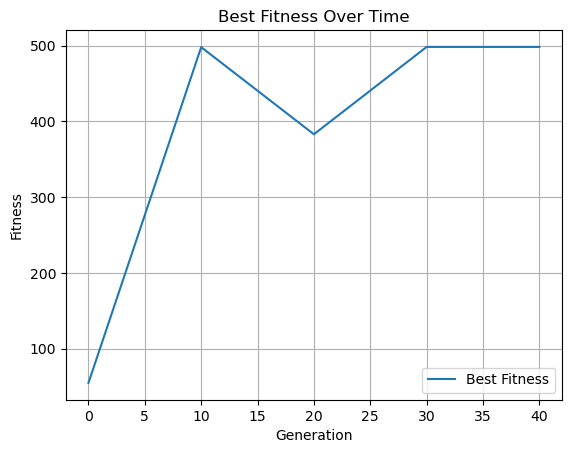

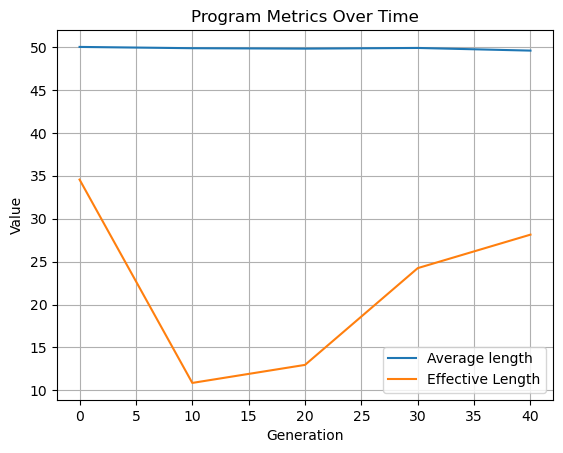

Best program with fitness 498.2 [['DIV', 'r5', 'r7', 'r4'],
['COS', 'r0', 'r3'],
['GT', 'r5', 'r6', 'r5'],
['DIV', 'r5', 'r2', 'r0'],
['MUL', 'r5', 'r0', 'r7'],
['COS', 'r5', 'r0'],
['LOAD', 'r6', -1],
['MUL', 'r6', 'r5', 'r3'],
['ADD', 'r5', 'r6', 'r3'],
['MUL', 'r5', 'r3', 'r4'],
['COS', 'r0', 'r2'],
['MUL', 'r5', 'r0', 'r7'],
['COS', 'r5', 'r0'],
['LOAD', 'r6', -1],
['MUL', 'r6', 'r5', 'r3'],
['COS', 'r0', 'r2'],
['COS', 'r0', 'r7'],
['ADD', 'r0', 'r2', 'r6']]
Best program length (Total, effective): 49, 18
Time: 36.90790220000781


In [5]:
# All environments which the system was tested on
# Theoretically works with any environment which has either Discrete or Box action spaces (from Gymnasium)
environments = ["CartPole-v1", "Acrobot-v1", "MountainCarContinuous-v0", "Pendulum-v1"][0:1]
reward_weights = [1, 1, 1, 1][0:1]
system = LinearGeneticProgrammingSystem(max_generations=50)
start = time.perf_counter()
best_program, best_fitness = system.evolve(stop_if_converged=True, environments=environments, reward_weights=reward_weights, parsimony_coefficient=0.1)
end = time.perf_counter()
system.display_statistics()
for env in environments:
    best_program.display_program(environment=env)
print(f"Best program with fitness {best_fitness}", best_program)
print(f"Best program length (Total, effective): {len(best_program)}, {len(best_program.effective_indices)}")
print("Time:", end - start)